# Day 3 — NumPy + Pandas + EDA Practice

**Data:** `machine_sensor_dirty.csv`

**Goal:** understand and analyze the data before ML.

This notebook follows the same exercise structure as the Day 3 `.py` file:

**NumPy → Pandas → Data Quality → Categorical/Numerical Analysis → GroupBy → Apply/Lambda → EDA**


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = '../day-02-python-reactivation/machine_sensor_dirty.csv'

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')
df['status'] = df['status'].str.strip().str.lower()
df = df.drop_duplicates()
sensor_cols = ['temperature','vibration','pressure']
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].mean())
df.head()


,machine_id,temperature,vibration,pressure,status
0,M01,65.0,1.200000,42.0,running
1,M02,91.0,2.800000,55.0,running
2,M03,72.0,2.336364,39.0,running
3,M04,88.0,3.000000,61.0,warning
4,M05,69.0,1.500000,53.0,running


## BLOCK A — NUMPY

### EXERCISE 1 — Sensor Array

A machine produced these temperature readings:

`[65, 91, 72, 88, 69, 76, 95, 84, 79, 102]`

Convert to a NumPy array and inspect:

- type
- ndim
- shape
- size
- dtype


In [46]:
temperature_readings = [65, 91, 72, 88, 69, 76, 95, 84, 79, 102]

# TODO
arr = np.array(temperature_readings)

print(f'''
type    : {type(arr)}
ndim    : {arr.ndim}
shape   : {arr.shape}
size    : {arr.size}
dtype   : {arr.dtype}
''')



type    : <class 'numpy.ndarray'>
ndim    : 1
shape   : (10,)
size    : 10
dtype   : int64



### EXERCISE 2 — NumPy Conditions

Using `arr`:

A) first 5 readings  
B) last 3 readings  
C) readings > 80  
D) readings between 70 and 90

Use NumPy boolean masking for C and D.


In [47]:
print(f'''
First 5:
{arr[:5]}

Last 3:
{arr[-3:]}

Above 80:
{arr[arr > 80]}

Between 70 and 90:
{arr[(arr > 70) & (arr < 90)]}
''')



First 5:
[65 91 72 88 69]

Last 3:
[ 84  79 102]

Above 80:
[ 91  88  95  84 102]

Between 70 and 90:
[72 88 76 84 79]



### EXERCISE 3 — NumPy Statistics

Calculate:

- mean
- min
- max
- variance
- standard deviation
- sum


In [48]:
# EXERCISE 3 — NumPy Statistics
"""
Calculate:
- mean
- min
- max
- variance
- standard deviation
- sum
"""
arr.mean()
arr.min()
arr.max()
arr.var()
arr.std()
arr.sum()


df1=pd.DataFrame(temperature_readings)
df1.agg(['mean', 'min', 'max', 'var', 'std'])

#df[["temperature","vibration","pressure"]].agg(["mean", "min", "max", "var", "std", "sum"])

# One advantage of using NumPy arrays is that they make statistical calculations easier and more efficient.



,0
mean,82.100000
min,65.000000
max,102.000000
var,143.655556
std,11.985640


### EXERCISE 4 — Sensor Matrix

Rows are machines.
Columns are `[temperature, vibration, pressure]`.

Build:

```text
[
    [65, 1.2, 42],
    [91, 2.8, 55],
    [72, 1.1, 39],
    [88, 3.0, 61],
]
```

Inspect:

- shape
- first row
- second row, third column
- all rows, first column
- first two columns


In [49]:
# TODO
"""sensor_matrix = np.array([
    [65, 1.2, 42],
    [91, 2.8, 55],
    [72, 1.1, 39],
    [88, 3.0, 61],
])"""

# Practice indexing below.
# print(sensor_matrix.shape)
# print(sensor_matrix[0])
# print(sensor_matrix[1, 2])
# print(sensor_matrix[:, 0])
# print(sensor_matrix[:, :2])
# EXERCISE 4 — Sensor Matrix
"""
Rows are machines.
Columns are [temperature, vibration, pressure].

Build:
[
    [65, 1.2, 42],
    [91, 2.8, 55],
    [72, 1.1, 39],
    [88, 3.0, 61],
]

Inspect shape and practice row/column indexing.
"""
machine_array=[
    [65, 1.2, 42],
    [91, 2.8, 55],
    [72, 1.1, 39],
    [88, 3.0, 61],
]

machines=np.array(machine_array)
print(machines)
machines.shape
machines[:,:2] #comma is important for 2D and 3D  arr[depth, row, column]
machines[:2]
machines[1:,:2] #arr[row,column]
machines[1:3] # it executes it that like index , start from 1.index to 3 except 3

[[65.   1.2 42. ]
 [91.   2.8 55. ]
 [72.   1.1 39. ]
 [88.   3.  61. ]]


array([[91. ,  2.8, 55. ],
       [72. ,  1.1, 39. ]])

## BLOCK B — PANDAS FOUNDATIONS

### EXERCISE 5 — Load and Inspect

Read `machine_sensor_dirty.csv` into `df`.

Inspect:

- `head()`
- `shape`
- `columns`
- `dtypes`
- `info()`


In [50]:
# TODO
#df = pd.read_csv(DATA_PATH)

#df.head()
# EXERCISE 5 — Load and Inspect
"""
Read machine_sensor_dirty.csv into df.

Inspect:
- head()
- shape
- columns
- dtypes
- info()
"""
#machines_array=np.array(df[["temperature","vibration","pressure"]])
machines_array=df[["temperature","vibration","pressure"]].to_numpy()
machines=pd.DataFrame(machines_array,columns=["temperature","vibration","pressure"])
print(f"""
Head              :\n{machines.head()}
Shape             :\n{machines.shape}
Columns           :\n{machines.columns}
Dtypes            :\n{machines.dtypes}
Info              :\n{machines.info()}
""")


<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  12 non-null     float64
 1   vibration    12 non-null     float64
 2   pressure     12 non-null     float64
dtypes: float64(3)
memory usage: 420.0 bytes

Head              :
   temperature  vibration  pressure
0         65.0   1.200000      42.0
1         91.0   2.800000      55.0
2         72.0   2.336364      39.0
3         88.0   3.000000      61.0
4         69.0   1.500000      53.0
Shape             :
(12, 3)
Columns           :
Index(['temperature', 'vibration', 'pressure'], dtype='str')
Dtypes            :
temperature    float64
vibration      float64
pressure       float64
dtype: object
Info              :
None



In [51]:
# TODO
print(df.shape)
print(df.columns)
print(df.dtypes)

df.info()


(12, 5)
Index(['machine_id', 'temperature', 'vibration', 'pressure', 'status'], dtype='str')
machine_id         str
temperature    float64
vibration      float64
pressure       float64
status             str
dtype: object
<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   machine_id   12 non-null     str    
 1   temperature  12 non-null     float64
 2   vibration    12 non-null     float64
 3   pressure     12 non-null     float64
 4   status       12 non-null     str    
dtypes: float64(3), str(2)
memory usage: 576.0 bytes


### EXERCISE 6 — Series vs DataFrame

Compare:

```python
df["temperature"]
df[["temperature"]]
```

Print their values and types.

Explain the difference in one comment.


In [52]:
# EXERCISE 6 — Series vs DataFrame
"""
Compare:
df["temperature"]
df[["temperature"]]

Print their values and types.
Explain the difference in one comment.
"""
print(f'''
{type(df["temperature"])}
{type(df[["temperature"]])}''')
#first gives value of temperature
#second gives column of temperature



<class 'pandas.Series'>
<class 'pandas.DataFrame'>


### EXERCISE 7 — Column Selection

Create:

A) `machine_id + temperature + vibration`  
B) `machine_id + status`


In [53]:
print(f"""
{df[["machine_id","temperature","vibration"]]}
{df[["machine_id","status"]]}
{df.loc[:,["machine_id","temperature","vibration"]]}
{df.loc[:,["machine_id","status"]]}
""")


   machine_id  temperature  vibration
0         M01         65.0   1.200000
1         M02         91.0   2.800000
2         M03         72.0   2.336364
3         M04         88.0   3.000000
4         M05         69.0   1.500000
5         M06         82.1   2.100000
7         M07         76.0   1.700000
8         M08         95.0   3.400000
9         M09         82.1   1.300000
10        M10         84.0   2.600000
11        M11         79.0   2.000000
12        M12        102.0   4.100000
   machine_id    status
0         M01   running
1         M02   running
2         M03   running
3         M04   warning
4         M05   running
5         M06   stopped
7         M07   running
8         M08  critical
9         M09   running
10        M10   warning
11        M11   running
12        M12  critical
   machine_id  temperature  vibration
0         M01         65.0   1.200000
1         M02         91.0   2.800000
2         M03         72.0   2.336364
3         M04         88.0   3.000000
4  

### EXERCISE 8 — Row Selection

Use `loc` and `iloc`:

A) first row  
B) first three rows  
C) row with index 1  
D) first two rows + selected columns


In [54]:
df.iloc[0,:]
df.iloc[0:3,:]
df.iloc[1,:]
df.loc[0:2,["temperature","status"]]
#df.head()

,temperature,status
0,65.0,running
1,91.0,running
2,72.0,running


### EXERCISE 9 — Filtering

Answer:

A) temperature > 80  
B) vibration > 2.5  
C) pressure > 50  
D) temperature > 85 OR vibration > 2.5


In [55]:
df.loc[df["temperature"]>80,:]
df.loc[df["vibration"]>2.5,:]
df.loc[df["pressure"]>50,:]
df.loc[(df["temperature"]>80) | (df["vibration"]>2.5),:]

,machine_id,temperature,vibration,pressure,status
1,M02,91.0,2.8,55.0,running
3,M04,88.0,3.0,61.0,warning
5,M06,82.1,2.1,47.0,stopped
8,M08,95.0,3.4,70.0,critical
9,M09,82.1,1.3,41.0,running
10,M10,84.0,2.6,58.0,warning
12,M12,102.0,4.1,74.0,critical


## BLOCK C — DATA QUALITY

### EXERCISE 10 — Missing Values

Count missing values per column.

Display rows missing temperature, vibration or pressure.

**Do not clean yet.**


In [56]:
df_raw.isna().sum()
df_raw[df_raw["temperature"].isna()] # if you want to use this method you execute just for a value otherwise you have to use "any" after isna()
df_raw[df_raw[["temperature","vibration","pressure"]].isna().any(axis=1)]
#df_raw


,machine_id,temperature,vibration,pressure,status
2,M03,72,NaN,39.0,running
4,M05,69,1.5,NaN,running
9,M09,NaN,1.3,41.0,running


### EXERCISE 11 — Duplicates

1. Count duplicates.
2. Display them.
3. Create `df_clean`.
4. Remove duplicates.
5. Compare before/after shape.

Keep `df` unchanged.


In [57]:
print(f'''
{df_raw.duplicated().sum()}
{df_raw.isna().sum()}''')


df_c=df_raw.copy()
df_c["temperature"]=pd.to_numeric(df_c["temperature"],errors="coerce")

df_c=df_c.drop_duplicates()

print(f'''
{df_raw.shape}
{df_c.shape}''')



1
machine_id     0
temperature    1
vibration      1
pressure       1
status         0
dtype: int64

(13, 5)
(12, 5)


### EXERCISE 12 — Descriptive Statistics

For temperature, vibration and pressure calculate:

- count
- mean
- median
- std
- min
- max
- 25%
- 50%
- 75%

Then compare your result with:

```python
df_clean.describe()
```


In [58]:
# TODO

# You may use agg() here.
# Example structure:
# df_clean[["temperature", "vibration", "pressure"]].agg([...])
df_c.describe()

df_c[["temperature", "vibration", "pressure"]].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.50),
    lambda x: x.quantile(0.75)])
print(f'''

{df_c[["temperature", "vibration", "pressure"]].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"])}
{df_c[["temperature", "vibration", "pressure"]].quantile([0.25,0.50,0.75])}''')




        temperature  vibration   pressure
count      10.00000  11.000000  11.000000
mean       82.10000   2.336364  53.000000
median     81.50000   2.100000  52.000000
std        11.98564   0.927656  11.840608
min        65.00000   1.200000  39.000000
max       102.00000   4.100000  74.000000
      temperature  vibration  pressure
0.25        73.00        1.6      43.0
0.50        81.50        2.1      52.0
0.75        90.25        2.9      59.5


### EXERCISE 13 — Mean vs Median Decision

For each numeric sensor:

- inspect `describe()`
- compare mean and median
- inspect a histogram
- inspect a boxplot

Decide which imputation approach is more sensible and explain why.

**Do not fill missing values yet.**


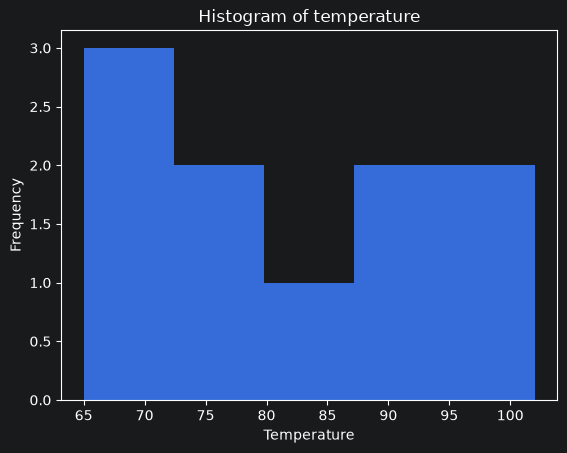

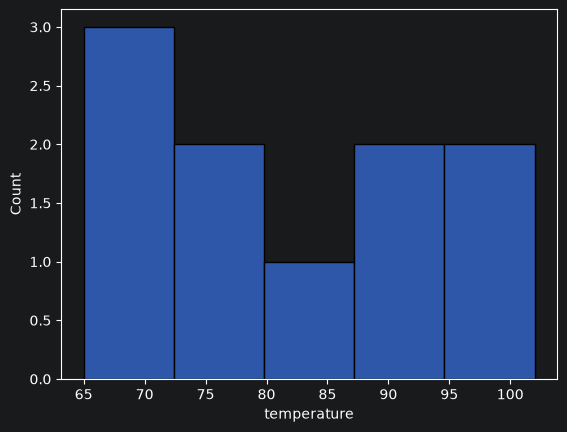

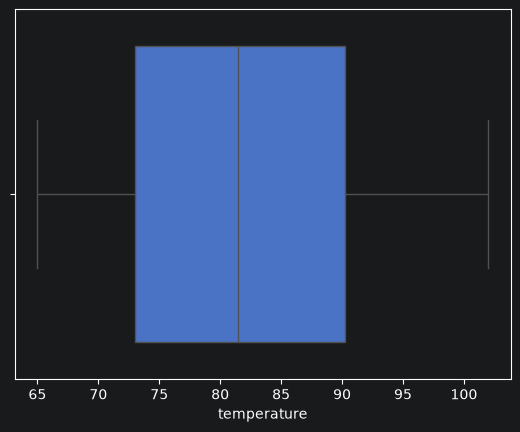

In [59]:
import seaborn as sns
df_c[["temperature", "vibration", "pressure"]].describe()

df_c[["temperature", "vibration", "pressure"]].agg(["mean","median"])
plt.hist(df_c["temperature"],bins=5)
plt.title("Histogram of temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

sns.histplot(data=df_c,x="temperature")
plt.show()

sns.boxplot(x="temperature",data=df_c)
plt.show()
# Decide and write your explanation in a Markdown cell.


The mean and median  are relatively close,suggesting limited skewness

## BLOCK D — CATEGORICAL + VISUAL ANALYSIS

### EXERCISE 14 — Normalize Status

Apply:

- `strip()`
- `lower()`

Then print unique values.


In [60]:
df_c
df_c["status"]=df_c["status"].str.strip().str.lower()


### EXERCISE 15 — Status Counts + Ratios

Use `value_counts()`.

Create a summary DataFrame with:

`status | count | ratio`


In [61]:

counts=df_c["status"].value_counts()
ratios=df_c["status"].value_counts(normalize=True)
df_status=pd.DataFrame({
    "count":counts,
    "ratio":ratios
})
df_status

,count,ratio
status,,
running,7,0.583333
warning,2,0.166667
critical,2,0.166667
stopped,1,0.083333


### EXERCISE 16 — Status Plot

Create a Seaborn/Matplotlib count plot with:

- title
- x label
- y label


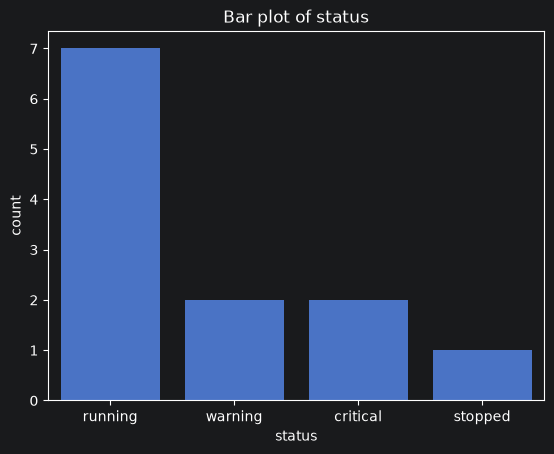

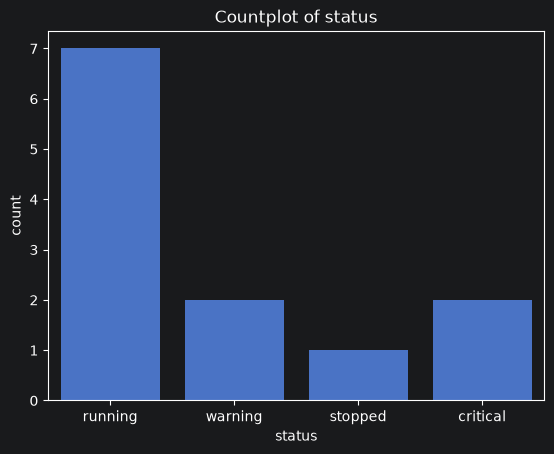

,count,ratio
status,,
running,7,0.583333
warning,2,0.166667
critical,2,0.166667
stopped,1,0.083333


In [62]:
#df_status=df_status.reset_index() #is useful when information stored in the index needs to be treated as a regular column.

sns.barplot(data=df_status,x="status",y="count")#draw
plt.title("Bar plot of status")
plt.show()
sns.countplot(data=df_c,x="status")# count and draw
plt.title("Countplot of status")
plt.show()
df_status


### EXERCISE 17 — Temperature Distribution

Create:

- temperature histogram
- temperature boxplot

Write one observation for each.


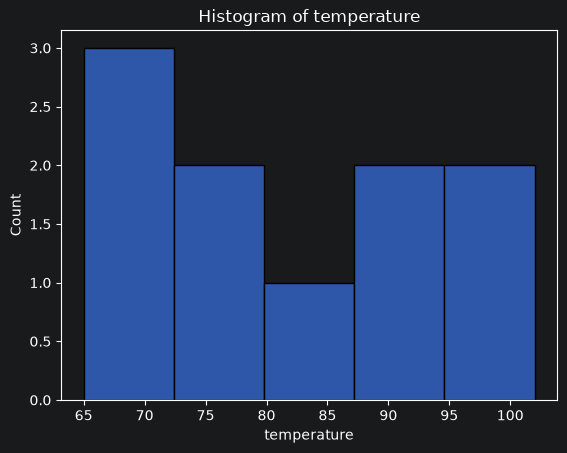

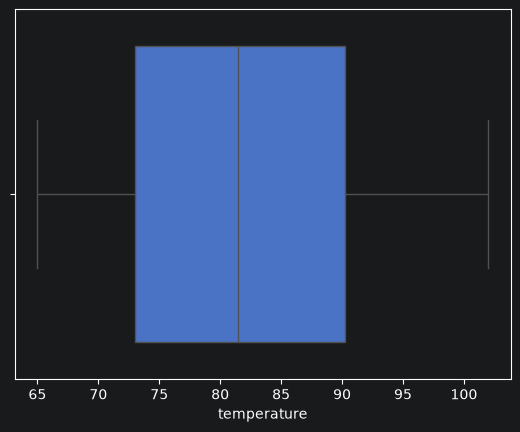

In [63]:
sns.histplot(data=df_c,x="temperature")
plt.title("Histogram of temperature")
plt.show()

sns.boxplot(data=df_c,x="temperature")
plt.show()

### EXERCISE 18 — Vibration + Pressure

Create histogram and boxplot for:

- vibration
- pressure

Be cautious with conclusions because the dataset is small.


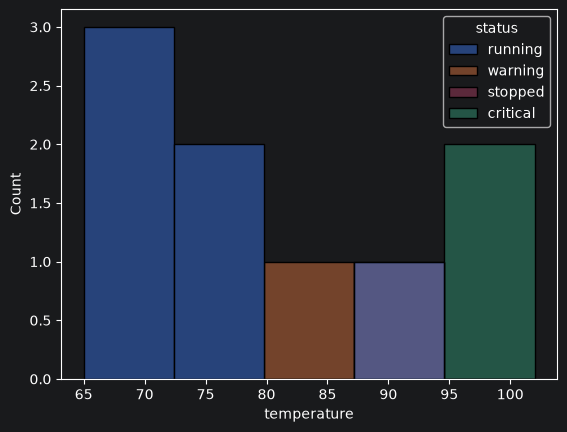

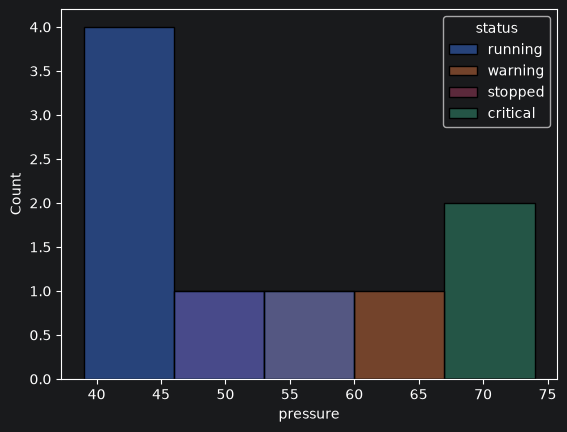

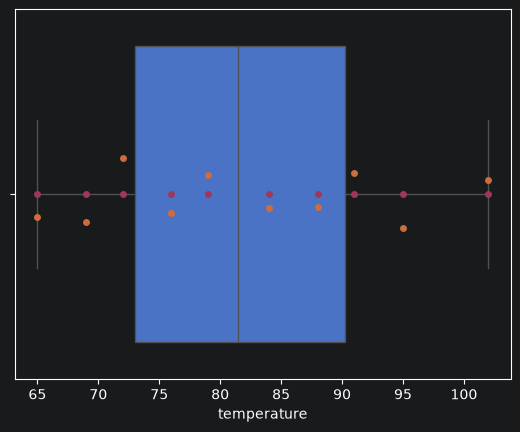

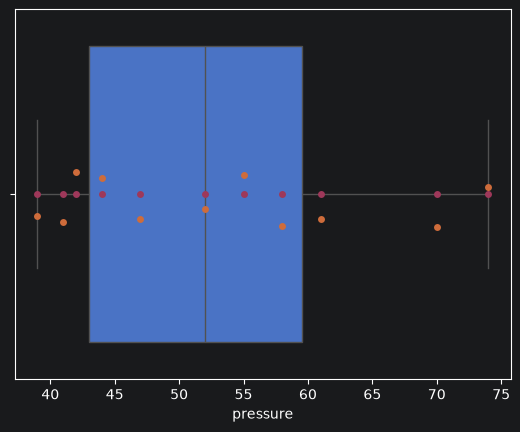

In [64]:
sns.histplot(data=df_c,x="temperature",hue="status")
plt.show()

sns.histplot(data=df_c,x="pressure",hue="status")
plt.show()

sns.boxplot(data=df_c,x="temperature")
sns.stripplot(data=df_c,x="temperature")
sns.swarmplot(data=df_c,x="temperature")
plt.show()
sns.boxplot(data=df_c,x="pressure")
sns.stripplot(data=df_c,x="pressure")
sns.swarmplot(data=df_c,x="pressure")
plt.show()


### EXERCISE 19 — Correlation

Calculate the correlation matrix for:

- temperature
- vibration
- pressure

Visualize it with a Seaborn heatmap.

Answer:

- strongest positive pair?
- weakest pair?
- does correlation prove causation?


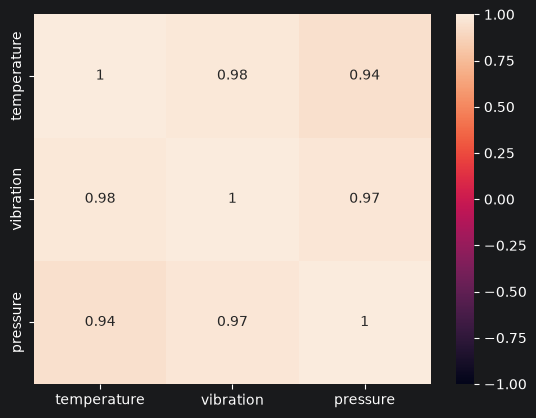

'\nstrongest positive pair?          : temperature and vibration\nweakest pair?                     : temperature and pressure\ndoes correlation prove causation? : No. Correlation does not imply causation, and this dataset is relatively small.\n\n'

In [65]:
df_corr=df_c[["temperature","vibration","pressure"]].corr()
sns.heatmap(
    data=df_corr,
    vmin=-1,
    vmax=1,
    annot=True)
plt.show()

"""
strongest positive pair?          : temperature and vibration
weakest pair?                     : temperature and pressure
does correlation prove causation? : No. Correlation does not imply causation, and this dataset is relatively small.

"""

## BLOCK E — GROUPBY / APPLY

### EXERCISE 20 — Status Group Analysis

Group by `status` and calculate:

- record count
- mean temperature
- mean vibration
- mean pressure


In [66]:
df_c["temperature"]=df_c["temperature"].fillna(df_c["temperature"].mean())
df_c["vibration"]=df_c["vibration"].fillna(df_c["vibration"].mean())
df_c["pressure"]=df_c["pressure"].fillna(df_c["pressure"].mean())
grouped=df_c.groupby("status").agg({
    "machine_id":"count",
    "temperature":"mean",
    "vibration":"mean",
    "pressure":"mean"
})

### EXERCISE 21 — Highest Mean Temperature Group

From the grouped result, identify the status with the highest mean temperature.

Use sorting/selection, not manual reading.


In [67]:
grouped.sort_values("temperature",ascending=False).head(1)


,machine_id,temperature,vibration,pressure
status,,,,
critical,2,98.5,3.75,72.0


### EXERCISE 22 — Multi-Aggregation

Create a compact summary using `agg()`:

```text
temperature → mean, median, max
vibration   → mean, max
pressure    → mean, min, max
```


In [68]:
df_c.agg(
    {"temperature":["mean","median","max"],"vibration":["mean","max"],"pressure":["mean","min","max"]}
)

,temperature,vibration,pressure
mean,82.1,2.336364,53.0
median,82.1,NaN,NaN
max,102.0,4.100000,74.0
min,NaN,NaN,39.0


### EXERCISE 23 — Apply / Lambda

Create `temperature_label`:

- temperature > 85 → `"critical"`
- otherwise → `"normal"`

Use `apply + lambda` once.

Then create the same result with a vectorized Pandas expression and compare them.


In [69]:
# Apply + lambda version
df_c["temperature_label1"]=df_c["temperature"].apply(
    lambda x: "critical" if x>85 else "normal"
)
"""
# Vectorized version
df_c["temperature_label"]=np.where(
    df_c["temperature"]>85,
    "critical",
    "normal"
)"""

df_c["temperature_label"]="normal"
df_c.loc[df_c["temperature"]>85,"temperature_label"]="critical"

# Optional: verify that the two columns are equal.
print(f"""
{df_c["temperature_label"].shape}
{df_c["temperature_label1"].shape}""")




(12,)
(12,)


### EXERCISE 24 — Severity Score

Learning-only:

- +1 temperature > 80
- +1 vibration > 2.0
- +1 pressure > 55

Create a risk/severity score and sort descending.

Explain why this is **not** a production ML model.


In [70]:
arr_t=np.array(df_c["temperature"]>80).astype(int)
arr_v=np.array(df_c["vibration"]>2.0).astype(int)
arr_p=np.array(df_c["pressure"]>55).astype(int)

risk_score=(arr_t+arr_v+arr_p)
df_c["risk_score"]=risk_score
df_c.sort_values("risk_score",ascending=False)



,machine_id,temperature,vibration,pressure,status,temperature_label1,temperature_label,risk_score
3,M04,88.0,3.000000,61.0,warning,critical,critical,3
12,M12,102.0,4.100000,74.0,critical,critical,critical,3
10,M10,84.0,2.600000,58.0,warning,normal,normal,3
8,M08,95.0,3.400000,70.0,critical,critical,critical,3
1,M02,91.0,2.800000,55.0,running,critical,critical,2
5,M06,82.1,2.100000,47.0,stopped,normal,normal,2
9,M09,82.1,1.300000,41.0,running,normal,normal,1
2,M03,72.0,2.336364,39.0,running,normal,normal,1
0,M01,65.0,1.200000,42.0,running,normal,normal,0
4,M05,69.0,1.500000,53.0,running,normal,normal,0


## BLOCK F — MINI EDA REPORT

### EXERCISE 25 — Five Questions

Answer with code:

1. row count after cleaning
2. column with most missing values before cleaning
3. hottest machine
4. highest-vibration machine
5. anomaly percentage under our learning rule


In [85]:
len(df_raw)
df_raw.isna().sum().sort_values(ascending=False)
df_c["temperature"].sort_values(ascending=False).head(1)
df_c["vibration"].sort_values(ascending=False).head(1)
anomaly_percentage=len(df_c[(df["temperature"]>80) | (df["vibration"]>2.5)])/len(df_c)
print(f"""{anomaly_percentage:.2%}""")


58.33%


### EXERCISE 26 — Three Useful Charts

Choose three charts that answer meaningful questions.

For each:

- title
- labels
- one-sentence interpretation



1. How are machine statuses distributed?
2. How are temperature values distributed?
3. Is there a relationship between temperature and vibration?

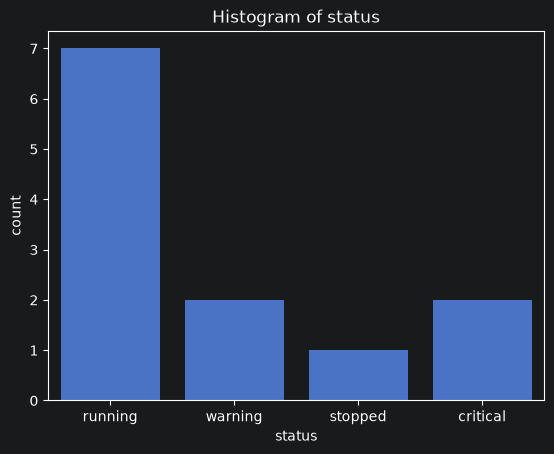

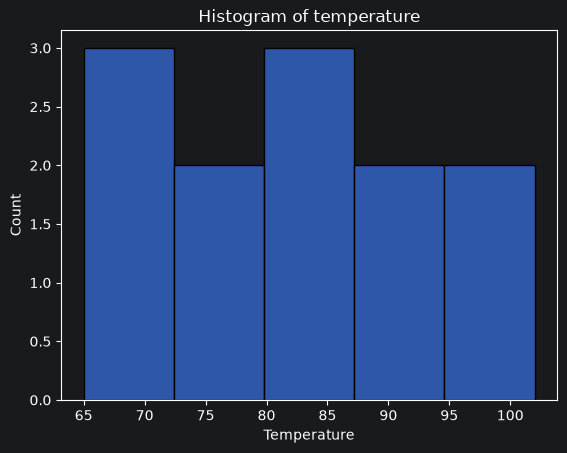

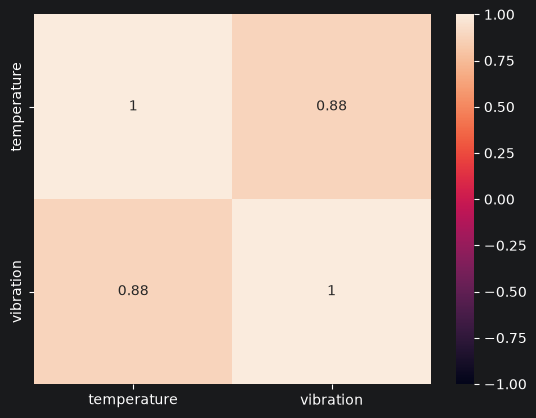

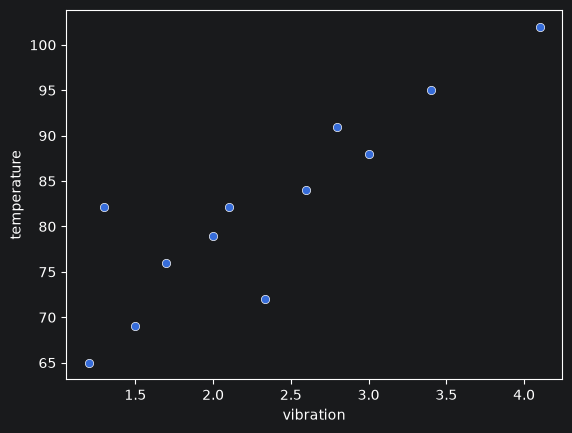

In [95]:
sns.countplot(data=df_c,x="status")
plt.title("Histogram of status")
plt.show()

sns.histplot(data=df_c,x="temperature")
plt.title("Histogram of temperature")
plt.xlabel("Temperature")
plt.show()


sns.heatmap(
    data=df_c[["temperature","vibration"]].corr(),
    vmin=-1,
    vmax=1,
    annot=True
)
plt.show()

sns.scatterplot(data=df_c,x="vibration",y="temperature")
plt.show()




### EXERCISE 27 — Reusable EDA Function

Write:

```python
basic_eda_report(df)
```

Return or print:

- observations
- variables
- missing values
- duplicates
- numeric columns
- categorical columns


In [102]:
def basic_eda_report(df):
    #df.head()
    #len(df)
    observations=df.shape[0]
    variables=df.shape[1]
    df.describe()
    missing_values=df.isna().sum()
    duplicates=df.duplicated().sum()

    numeric_columns=df.select_dtypes(include="number")
    categorical_columns=df.select_dtypes(include="str")

    print("Observations:", observations)
    print("Variables:", variables)
    print("Missing values:")
    print(missing_values)
    print("Duplicates:", duplicates)
    print("Numeric columns:", list(numeric_columns))
    print("Categorical columns:", list(categorical_columns))

basic_eda_report(df_raw)
#shabe(observation,variable)

Observations: 13
Variables: 5
Missing values:
machine_id     0
temperature    1
vibration      1
pressure       1
status         0
dtype: int64
Duplicates: 1
Numeric columns: ['vibration', 'pressure']
Categorical columns: ['machine_id', 'temperature', 'status']


## FINAL CHALLENGE — AI-FREE MINI EDA

In a **NEW blank notebook**, use `machine_sensor_dirty.csv`.

EDA=Exploratory Data Analysis = Keşifsel Veri Analizi.

Without looking at this notebook:

1. load
2. inspect
3. clean obvious problems
4. decide imputation
5. descriptive statistics
6. categorical analysis
7. numeric analysis
8. correlation
9. 3 useful charts
10. write a short EDA conclusion

Separate:

- what the data shows
- what is only a possible pattern
- what cannot be concluded because the dataset is tiny



--- HEAD ---
  machine_id temperature  vibration  pressure   status
0        M01          65        1.2      42.0  running
1        M02          91        2.8      55.0  running
2        M03          72        NaN      39.0  running
3        M04          88        3.0      61.0  WARNING
4        M05          69        1.5       NaN  running

--- SHAPE ---
(13, 5)

--- COLUMNS ---
Index(['machine_id', 'temperature', 'vibration', 'pressure', 'status'], dtype='str')

--- DTYPES ---
machine_id         str
temperature        str
vibration      float64
pressure       float64
status             str
dtype: object

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   machine_id   13 non-null     str    
 1   temperature  12 non-null     str    
 2   vibration    12 non-null     float64
 3   pressure     12 non-null     float64
 4   status       13 non-null

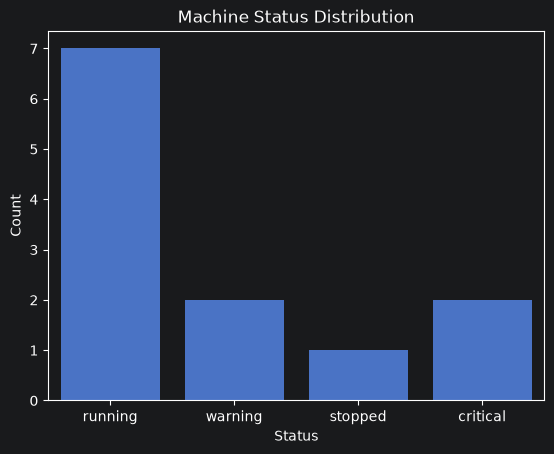

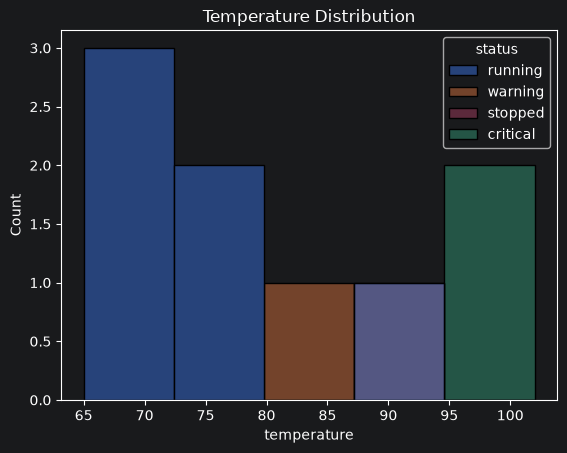

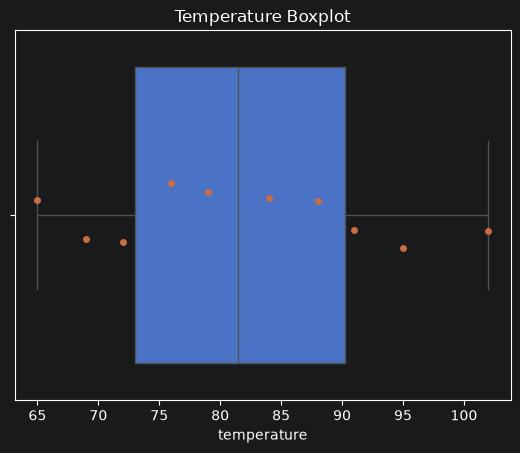

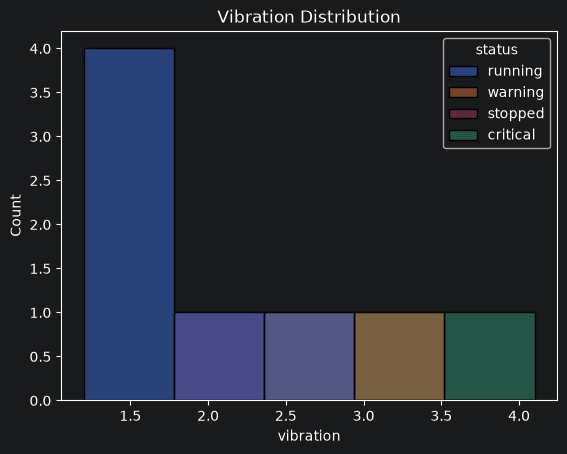

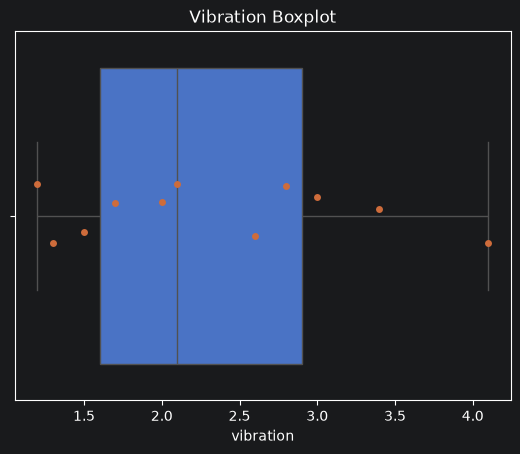

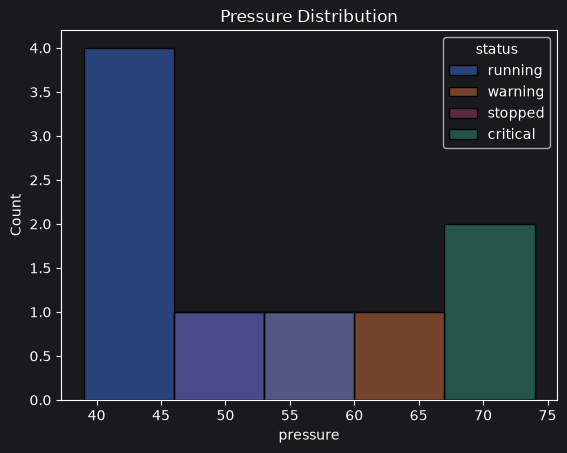

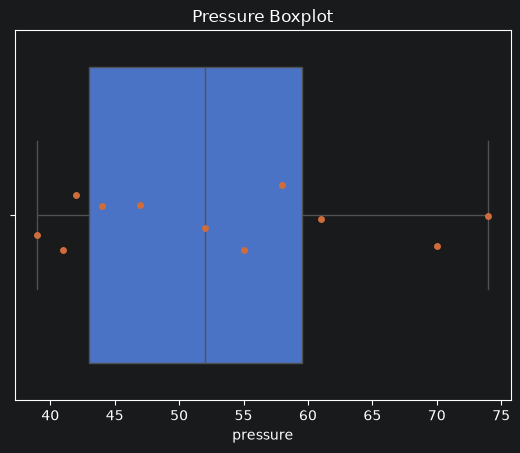


--- DESCRIPTIVE STATISTICS ---
       temperature  vibration   pressure
count     10.00000  11.000000  11.000000
mean      82.10000   2.336364  53.000000
std       11.98564   0.927656  11.840608
min       65.00000   1.200000  39.000000
25%       73.00000   1.600000  43.000000
50%       81.50000   2.100000  52.000000
75%       90.25000   2.900000  59.500000
max      102.00000   4.100000  74.000000

--- SKEWNESS ---
temperature : 0.1943310949111284
vibration   : 0.5549589092695388
pressure    : 0.5941576456174191

--- STATUS COUNTS ---
status
running     7
warning     2
critical    2
stopped     1
Name: count, dtype: int64

--- STATUS RATIOS ---
status
running     0.583333
warning     0.166667
critical    0.166667
stopped     0.083333
Name: proportion, dtype: float64


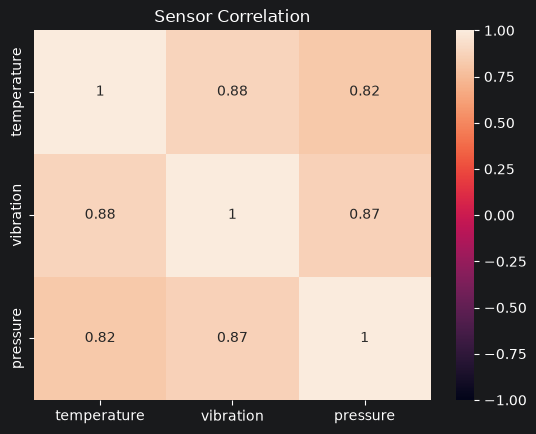

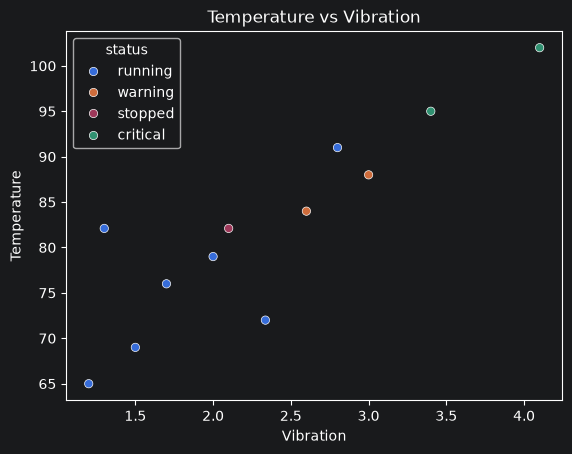

'\nWHAT THE DATA SHOWS:\n- ...\n\nPOSSIBLE PATTERNS:\n- ...\n\nWHAT CANNOT BE CONCLUDED:\n- ...\n'

In [132]:
# ============================================================
# EDA — EXPLORATORY DATA ANALYSIS
# ============================================================

# ============================================================
# 1. LOAD
# ============================================================

dff = pd.read_csv(DATA_PATH)


# ============================================================
# 2. INSPECT
# ============================================================

print("\n--- HEAD ---")
print(dff.head())

print("\n--- SHAPE ---")
print(dff.shape)

print("\n--- COLUMNS ---")
print(dff.columns)

print("\n--- DTYPES ---")
print(dff.dtypes)

print("\n--- INFO ---")
dff.info()

print("\n--- DESCRIBE ---")
print(dff.describe())


# ============================================================
# 3. DATA QUALITY / CLEANING
# ============================================================

# --- Data type check / conversion ---
dff["temperature"] = pd.to_numeric(
    dff["temperature"],
    errors="coerce"
)

# --- Missing values ---
print("\n--- MISSING VALUES ---")
print(dff.isna().sum())

# --- Duplicate values ---
print("\n--- DUPLICATES ---")
print(dff.duplicated().sum())

dff = dff.drop_duplicates()

# --- Normalize categorical data ---
dff["status"] = (
    dff["status"]
    .str.strip()
    .str.lower()
)

print("\n--- CLEANED DATA ---")
print(dff)


# ============================================================
# 4. DECIDE IMPUTATION
# ============================================================

# First inspect the distributions before filling NaN values.

# --- Status distribution ---
sns.countplot(data=dff, x="status")
plt.title("Machine Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# --- Temperature ---
sns.histplot(data=dff, x="temperature", hue="status")
plt.title("Temperature Distribution")
plt.show()

sns.boxplot(data=dff, x="temperature")
sns.stripplot(data=dff, x="temperature")
plt.title("Temperature Boxplot")
plt.show()

# --- Vibration ---
sns.histplot(data=dff, x="vibration", hue="status")
plt.title("Vibration Distribution")
plt.show()

sns.boxplot(data=dff, x="vibration")
sns.stripplot(data=dff, x="vibration")
plt.title("Vibration Boxplot")
plt.show()

# --- Pressure ---
sns.histplot(data=dff, x="pressure", hue="status")
plt.title("Pressure Distribution")
plt.show()

sns.boxplot(data=dff, x="pressure")
sns.stripplot(data=dff, x="pressure")
plt.title("Pressure Boxplot")
plt.show()


# ============================================================
# 5. DESCRIPTIVE STATISTICS
# ============================================================

print("\n--- DESCRIPTIVE STATISTICS ---")
print(dff[["temperature", "vibration", "pressure"]].describe())

print("\n--- SKEWNESS ---")
print("temperature :", dff["temperature"].skew())
print("vibration   :", dff["vibration"].skew())
print("pressure    :", dff["pressure"].skew())


# ============================================================
# 6. CATEGORICAL ANALYSIS
# ============================================================

print("\n--- STATUS COUNTS ---")
print(dff["status"].value_counts())

print("\n--- STATUS RATIOS ---")
print(dff["status"].value_counts(normalize=True))


# ============================================================
# 7. IMPUTATION
# ============================================================

# Choose mean/median based on the observations above.

dff["temperature"] = dff["temperature"].fillna(
     dff["temperature"].mean()
 )

dff["vibration"] = dff["vibration"].fillna(
     dff["vibration"].mean()
 )

dff["pressure"] = dff["pressure"].fillna(
     dff["pressure"].mean()
 )


# ============================================================
# 8. CORRELATION
# ============================================================

df_corr = dff[
    ["temperature", "vibration", "pressure"]
].corr()

sns.heatmap(
    data=df_corr,
    annot=True,
    vmin=-1,
    vmax=1
)

plt.title("Sensor Correlation")
plt.show()


# ============================================================
# 9. RELATIONSHIPS / USEFUL CHARTS
# ============================================================

sns.scatterplot(
    data=dff,
    x="vibration",
    y="temperature",
    hue="status"
)

plt.title("Temperature vs Vibration")
plt.xlabel("Vibration")
plt.ylabel("Temperature")
plt.show()


# ============================================================
# 10. EDA CONCLUSION
# ============================================================
"""
WHAT THE DATA SHOWS:
- The dataset contains machine sensor measurements such as temperature,
  vibration, and pressure, together with machine status information.
- Temperature, vibration, and pressure have different distributions and
  ranges.
- The status variable contains multiple machine conditions with different
  frequencies.
- The correlation analysis shows that temperature and vibration have a
  relatively strong positive correlation, while temperature and pressure
  have a weaker relationship.

POSSIBLE PATTERNS:
- Higher temperature values may be associated with higher vibration values.
- Some high sensor readings may be related to abnormal machine conditions.
- The distributions and boxplots suggest that some observations may be
  potential outliers.

WHAT CANNOT BE CONCLUDED:
- The observed correlations do not prove that one sensor causes another
  to change.
- The possible relationship between temperature and vibration cannot be
  generalized to all machines because the dataset is small.
- We cannot conclude that a specific sensor value causes machine failure
  without a larger dataset and a validated predictive model.
"""









## DAY 3 QUICK RECALL

Before moving on, make sure you can explain from memory:

- NumPy `ndarray`
- `shape`, `ndim`, `size`, `dtype`
- indexing and slicing
- 2D / 3D array indexing
- boolean masking
- vectorization
- DataFrame vs Series
- `loc` vs `iloc`
- `groupby`
- `agg`
- `apply` / `lambda`
- correlation
- skewness
- histogram vs boxplot
- why correlation does not imply causation
